# Uncertainty forecasting on the consumer-loans dataset

This notebook extends the signature-transform forecasting pipeline from point forecasts to **probabilistic forecasts** on the original consumer-loans dataset. The uncertainty layer is implemented through **weighted quantile regression**, which produces conditional quantiles and prediction intervals while keeping the same signature features and adaptive weighting scheme.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

import pandas as pd

from marketplace_signature_forecast.config import (
    ALL_HORIZONS,
    DEFAULT_DEPTH,
    DEFAULT_N_TARGET,
    DEFAULT_WINDOW_SIZE,
    END_DATE,
    FIGURES_DIR,
    FRED_API_KEY,
    START_DATE,
    N_VALIDATION,
    TARGET,
    DATA_DIR,
    ensure_directories,
)
from marketplace_signature_forecast.data_loading import build_data_dictionary, fetch_marketplace_series
from marketplace_signature_forecast.preprocessing import (
    build_model_dataset,
    prepare_standardized_arrays,
    resample_collection,
    resample_to_weekly,
    save_processed_bundle,
    train_validation_split,
)
from marketplace_signature_forecast.evaluation import run_multi_horizon_experiment
from marketplace_signature_forecast.plotting import plot_quantile_forecast_interval
from marketplace_signature_forecast.quantile_evaluation import run_multi_horizon_quantile_experiment

ensure_directories()

BASE_OUTPUT_DIR = DATA_DIR / "consumer_loans_uncertainty"
DATASET_DIR = BASE_OUTPUT_DIR / "dataset"
Y_ONLY_DIR = BASE_OUTPUT_DIR / "signature_y_only_quantiles"
JOINT_DIR = BASE_OUTPUT_DIR / "signature_joint_path_quantiles"
POINT_Y_ONLY_DIR = BASE_OUTPUT_DIR / "point_y_only"
POINT_JOINT_DIR = BASE_OUTPUT_DIR / "point_joint_path"
PLOT_DIR = FIGURES_DIR / "consumer_loans_uncertainty"

for directory in [BASE_OUTPUT_DIR, DATASET_DIR, Y_ONLY_DIR, JOINT_DIR, POINT_Y_ONLY_DIR, POINT_JOINT_DIR, PLOT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

QUANTILES = [0.1, 0.5, 0.9]
QUANTILE_ALPHA = 1e-2
WINDOW_SIZE = DEFAULT_WINDOW_SIZE
DEPTH = DEFAULT_DEPTH
N_TARGET = DEFAULT_N_TARGET
PLOT_HORIZON = 12
ADD_TIME = True

data_dictionary = build_data_dictionary()
data_dictionary

,variable,type,source,code,description,frequency
0,consumer_loans,target (y),FRED,CCLACBW027SBOG,Consumer Loans: Credit Cards and Other Revolvi...,"Weekly, Ending Wednesday"
1,sp500,input (x),FRED,SP500,S&P 500 Stock Price,Daily
2,bank_credit,input (x),FRED,TOTBKCR,"Bank Credit, All Commercial Banks",Weekly (Wed)
3,gas_price,input (x),FRED,GASREGW,U.S. Regular All Formulations Gas Price,Weekly (Mon)
4,loans_leases,input (x),FRED,TOTLL,"Loans and Leases in Bank Credit, All Commercia...",Weekly (Wed)
5,securities,input (x),FRED,SBCACBW027SBOG,"Securities in Bank Credit, All Commercial Bank...",Weekly (Wed)
6,ovx,input (x),FRED,OVXCLS,CBOE Crude Oil ETF Volatility Index,Daily
7,wti_crude,input (x),FRED,DCOILWTICO,Crude Oil Prices: West Texas Intermediate (WTI),Daily
8,brent_crude,input (x),FRED,DCOILBRENTEU,Crude Oil Prices: Brent - Europe,Daily
9,amazon_stock,input (x),Yahoo Finance,AMZN,Amazon Inc. Stock Price (Close),Daily


## 1. Rebuild the weekly dataset

In [2]:
y_raw, x_raw = fetch_marketplace_series(FRED_API_KEY, START_DATE, END_DATE)
y_weekly = resample_to_weekly(y_raw)
x_weekly = resample_collection(x_raw)
full_data = build_model_dataset(y_weekly, x_weekly).dropna().copy()
train_data, validation_data = train_validation_split(full_data, N_VALIDATION)

save_processed_bundle(full_data, train_data, validation_data, data_dictionary, DATASET_DIR)

print(full_data.shape)
print(full_data.index.min(), full_data.index.max())
full_data.head()

(365, 10)
2018-01-03 00:00:00 2024-12-25 00:00:00


,consumer_loans,sp500,bank_credit,gas_price,loans_leases,securities,ovx,wti_crude,brent_crude,amazon_stock
date,,,,,,,,,,
2018-01-03,767.8695,2713.06,12565.5385,2.520,9126.9922,3438.5462,22.75,61.61,67.85,60.209999
2018-01-10,768.5149,2748.23,12562.5932,2.522,9132.8667,3429.7264,23.52,63.60,69.79,62.716499
2018-01-17,769.6011,2802.56,12570.4123,2.557,9145.0310,3425.3813,24.78,63.92,69.19,64.750000
2018-01-24,767.3849,2837.54,12573.2215,2.567,9146.0674,3427.1541,23.93,65.69,69.91,67.875504
2018-01-31,769.3092,2823.81,12578.5406,2.607,9154.8997,3423.6409,22.23,64.82,67.78,72.544502


## 2. Standardized arrays

In [3]:
prepared = prepare_standardized_arrays(
    full_data=full_data,
    target_col=TARGET["name"],
    horizons=ALL_HORIZONS,
    n_validation=N_VALIDATION,
)

X = prepared["X"]
y = prepared["y"]
dates = prepared["dates"]
y_scaler = prepared["y_scaler"]

print(X.shape, y.shape)

(365, 9) (365,)


## 3. Probabilistic forecast: target-path signature only

In [4]:
quantile_results_y_only, quantile_summary_y_only = run_multi_horizon_quantile_experiment(
    X=X,
    y=y,
    dates=dates,
    y_scaler=y_scaler,
    horizons=ALL_HORIZONS,
    n_validation=N_VALIDATION,
    window_size=WINDOW_SIZE,
    depth=DEPTH,
    quantiles=QUANTILES,
    output_dir=Y_ONLY_DIR,
    alpha=QUANTILE_ALPHA,
    n_target=N_TARGET,
    use_sig_y_only=True,
    add_time=ADD_TIME,
)

quantile_summary_y_only = quantile_summary_y_only.rename(
    columns={
        "pinball_q0_1": "pinball_q0_1_y_only",
        "pinball_q0_5": "pinball_q0_5_y_only",
        "pinball_q0_9": "pinball_q0_9_y_only",
        "median_mae": "median_mae_y_only",
        "median_rmse": "median_rmse_y_only",
        "median_mre": "median_mre_y_only",
        "interval_coverage": "interval_coverage_y_only",
        "avg_interval_width": "avg_interval_width_y_only",
    }
)
quantile_summary_y_only

,pinball_q0_1_y_only,pinball_q0_5_y_only,pinball_q0_9_y_only,median_mae_y_only,median_rmse_y_only,median_mre_y_only,interval_coverage_y_only,avg_interval_width_y_only,horizon_weeks,n_forecasts
0,0.734933,1.268311,0.564505,2.536621,3.006947,0.235784,0.416667,5.099006,1,12
1,1.080446,1.720857,0.787573,3.441714,4.011375,0.319714,0.333333,4.676520,2,12
2,1.156426,1.623706,0.587289,3.247412,4.577793,0.301634,0.583333,4.784323,3,12
3,0.881656,1.529658,0.661742,3.059317,4.235758,0.284248,0.583333,5.365804,4,12
4,1.017539,1.424172,0.692387,2.848344,3.544875,0.264884,0.500000,6.264319,6,12
5,0.856447,1.288957,0.916327,2.577914,3.141328,0.239850,0.500000,9.594273,8,12
6,1.344306,1.791839,1.090180,3.583678,4.743413,0.333410,0.583333,11.090335,12,12


## 4. Probabilistic forecast: joint-path signature

In [5]:
quantile_results_joint, quantile_summary_joint = run_multi_horizon_quantile_experiment(
    X=X,
    y=y,
    dates=dates,
    y_scaler=y_scaler,
    horizons=ALL_HORIZONS,
    n_validation=N_VALIDATION,
    window_size=WINDOW_SIZE,
    depth=DEPTH,
    quantiles=QUANTILES,
    output_dir=JOINT_DIR,
    alpha=QUANTILE_ALPHA,
    n_target=N_TARGET,
    use_sig_y_only=False,
    add_time=ADD_TIME,
)

quantile_summary_joint = quantile_summary_joint.rename(
    columns={
        "pinball_q0_1": "pinball_q0_1_joint",
        "pinball_q0_5": "pinball_q0_5_joint",
        "pinball_q0_9": "pinball_q0_9_joint",
        "median_mae": "median_mae_joint",
        "median_rmse": "median_rmse_joint",
        "median_mre": "median_mre_joint",
        "interval_coverage": "interval_coverage_joint",
        "avg_interval_width": "avg_interval_width_joint",
    }
)
quantile_summary_joint

,pinball_q0_1_joint,pinball_q0_5_joint,pinball_q0_9_joint,median_mae_joint,median_rmse_joint,median_mre_joint,interval_coverage_joint,avg_interval_width_joint,horizon_weeks,n_forecasts
0,1.014083,1.475157,0.925178,2.950315,3.530589,0.274164,0.333333,2.939393,1,12
1,1.570442,2.232777,1.060893,4.465554,5.202706,0.415107,0.250000,4.838713,2,12
2,1.965294,2.274839,0.964531,4.549677,6.199643,0.423285,0.333333,6.213810,3,12
3,1.780199,3.040230,1.064853,6.080460,6.998356,0.565320,0.333333,8.364622,4,12
4,0.703013,2.161632,0.840404,4.323263,4.897412,0.401905,0.833333,11.098830,6,12
5,0.736639,1.793489,0.628087,3.586978,4.482896,0.333641,0.750000,8.847882,8,12
6,1.399245,1.888176,1.005047,3.776352,4.677259,0.351318,0.666667,11.407869,12,12


## 5. Compare probabilistic and point forecasts

In [6]:
point_results_y_only, point_summary_y_only = run_multi_horizon_experiment(
    X=X,
    y=y,
    dates=dates,
    y_scaler=y_scaler,
    horizons=ALL_HORIZONS,
    n_validation=N_VALIDATION,
    window_size=WINDOW_SIZE,
    depth=DEPTH,
    n_target=N_TARGET,
    output_dir=POINT_Y_ONLY_DIR,
    use_sig_y_only=True,
    add_time=ADD_TIME,
)

point_results_joint, point_summary_joint = run_multi_horizon_experiment(
    X=X,
    y=y,
    dates=dates,
    y_scaler=y_scaler,
    horizons=ALL_HORIZONS,
    n_validation=N_VALIDATION,
    window_size=WINDOW_SIZE,
    depth=DEPTH,
    n_target=N_TARGET,
    output_dir=POINT_JOINT_DIR,
    use_sig_y_only=False,
    add_time=ADD_TIME,
)

summary_table = quantile_summary_y_only.merge(
    quantile_summary_joint,
    on=["horizon_weeks", "n_forecasts"],
    how="outer",
).merge(
    point_summary_y_only.rename(columns={"signature_mre": "point_mre_y_only"}),
    on=["horizon_weeks", "n_forecasts"],
    how="left",
).merge(
    point_summary_joint.rename(columns={"signature_mre": "point_mre_joint"}),
    on=["horizon_weeks", "n_forecasts"],
    how="left",
)

summary_table.to_csv(BASE_OUTPUT_DIR / "consumer_loans_uncertainty_summary.csv", index=False)
summary_table.round(3)

c:\Users\tsito\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:664: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 5.931557523317088e-05, tolerance: 2.852047329991216e-05
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\tsito\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:664: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 5.1884625580506105e-05, tolerance: 4.2935784649484596e-05
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\tsito\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:664: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.00012182996224868736, tolerance: 4.145949899145642e-05
  model = cd_fast.enet_co

,pinball_q0_1_y_only,pinball_q0_5_y_only,pinball_q0_9_y_only,median_mae_y_only,median_rmse_y_only,median_mre_y_only,interval_coverage_y_only,avg_interval_width_y_only,horizon_weeks,n_forecasts,pinball_q0_1_joint,pinball_q0_5_joint,pinball_q0_9_joint,median_mae_joint,median_rmse_joint,median_mre_joint,interval_coverage_joint,avg_interval_width_joint,point_mre_y_only,point_mre_joint
0,0.735,1.268,0.565,2.537,3.007,0.236,0.417,5.099,1,12,1.014,1.475,0.925,2.950,3.531,0.274,0.333,2.939,0.249,0.283
1,1.080,1.721,0.788,3.442,4.011,0.320,0.333,4.677,2,12,1.570,2.233,1.061,4.466,5.203,0.415,0.250,4.839,0.334,0.514
2,1.156,1.624,0.587,3.247,4.578,0.302,0.583,4.784,3,12,1.965,2.275,0.965,4.550,6.200,0.423,0.333,6.214,0.307,0.833
3,0.882,1.530,0.662,3.059,4.236,0.284,0.583,5.366,4,12,1.780,3.040,1.065,6.080,6.998,0.565,0.333,8.365,0.381,1.027
4,1.018,1.424,0.692,2.848,3.545,0.265,0.500,6.264,6,12,0.703,2.162,0.840,4.323,4.897,0.402,0.833,11.099,0.392,1.105
5,0.856,1.289,0.916,2.578,3.141,0.240,0.500,9.594,8,12,0.737,1.793,0.628,3.587,4.483,0.334,0.750,8.848,0.569,1.364
6,1.344,1.792,1.090,3.584,4.743,0.333,0.583,11.090,12,12,1.399,1.888,1.005,3.776,4.677,0.351,0.667,11.408,1.231,0.995


## 6. Prediction intervals for a 12-week horizon

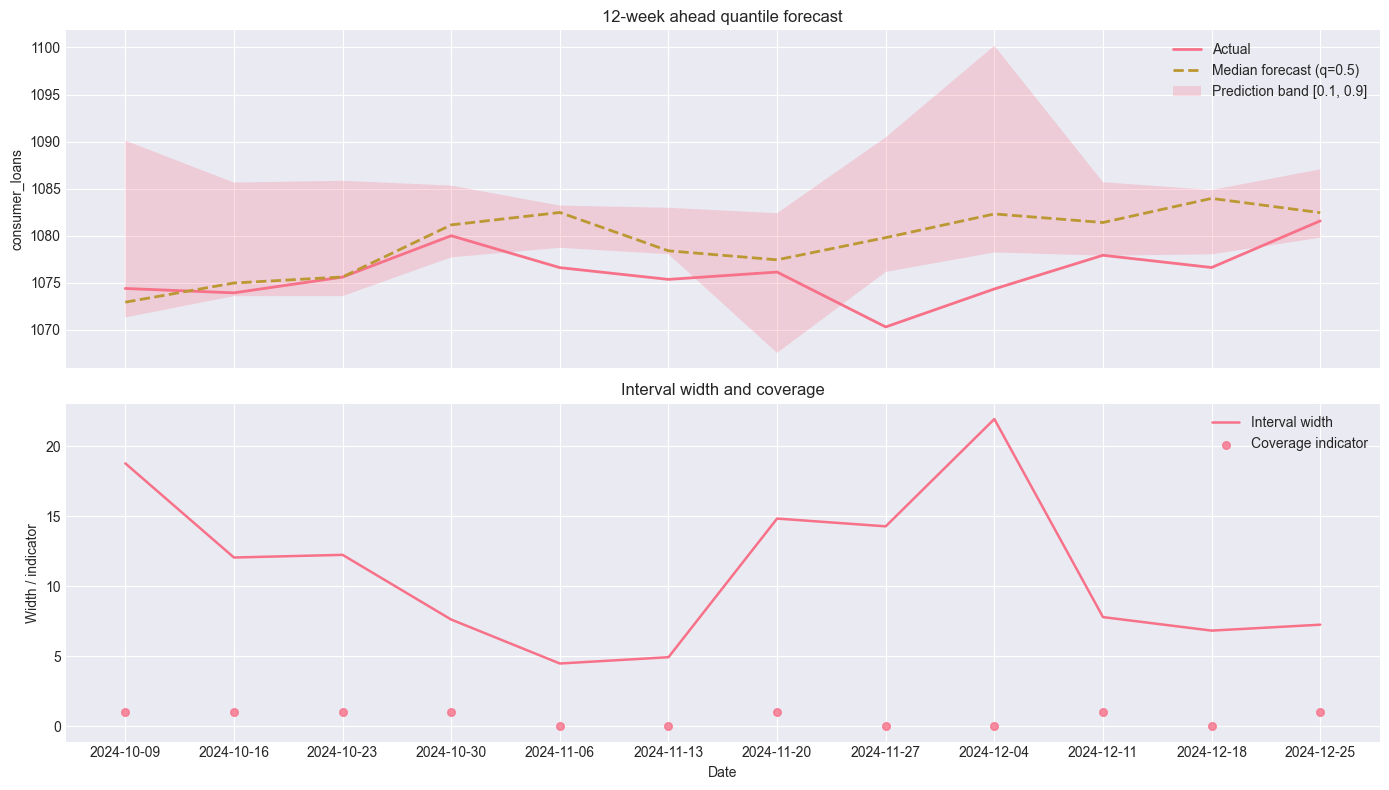

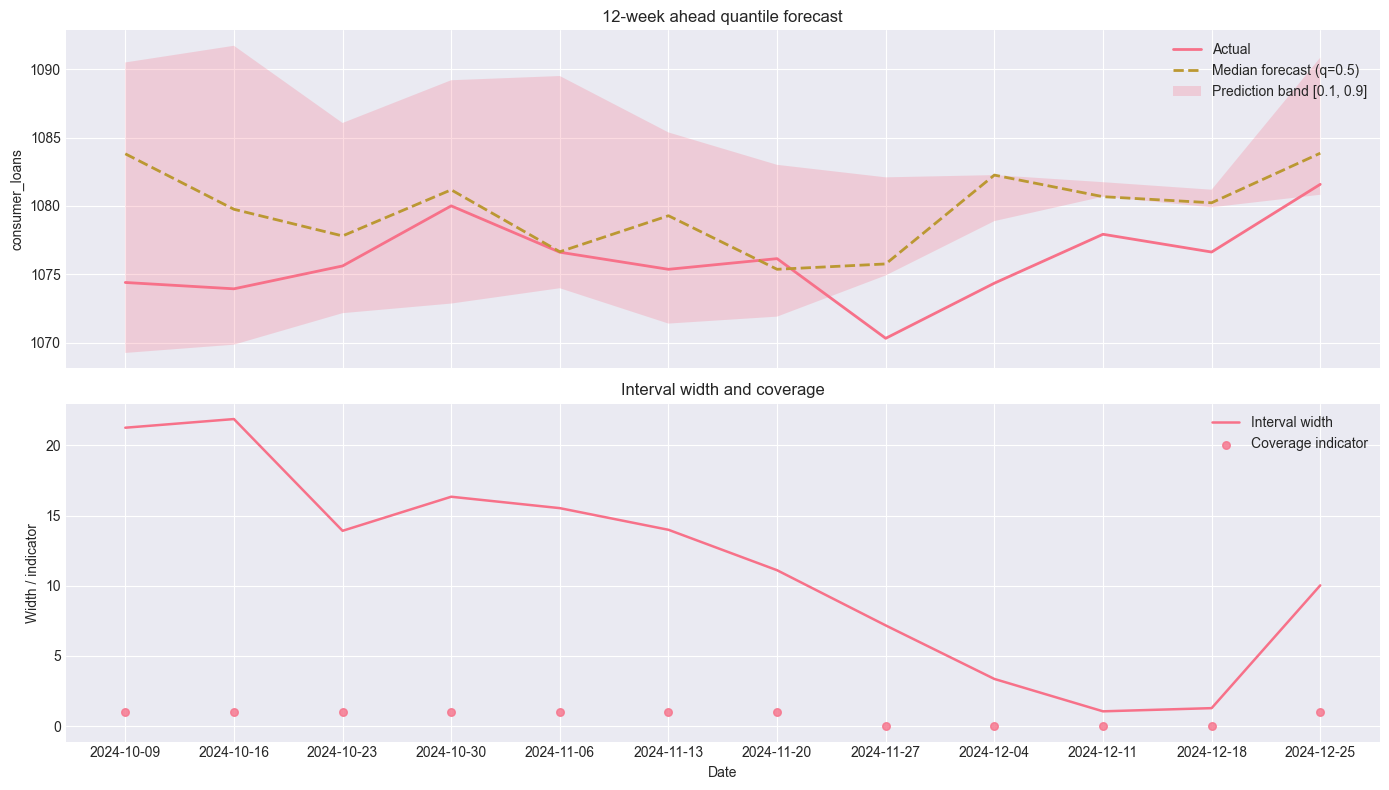

,6
pinball_q0_1_y_only,1.344306
pinball_q0_5_y_only,1.791839
pinball_q0_9_y_only,1.090180
median_mae_y_only,3.583678
median_rmse_y_only,4.743413
median_mre_y_only,0.333410
interval_coverage_y_only,0.583333
avg_interval_width_y_only,11.090335
horizon_weeks,12.000000
n_forecasts,12.000000


In [7]:
forecast_y_only = pd.read_csv(Y_ONLY_DIR / f"quantile_forecast_results_delta{PLOT_HORIZON}.csv")
forecast_joint = pd.read_csv(JOINT_DIR / f"quantile_forecast_results_delta{PLOT_HORIZON}.csv")

plot_quantile_forecast_interval(
    forecast_df=forecast_y_only,
    delta_t=PLOT_HORIZON,
    target_label=TARGET["name"],
    path=PLOT_DIR / f"consumer_loans_interval_y_only_delta{PLOT_HORIZON}.png",
)

plot_quantile_forecast_interval(
    forecast_df=forecast_joint,
    delta_t=PLOT_HORIZON,
    target_label=TARGET["name"],
    path=PLOT_DIR / f"consumer_loans_interval_joint_delta{PLOT_HORIZON}.png",
)

summary_table.loc[summary_table["horizon_weeks"] == PLOT_HORIZON].T